<a href="https://colab.research.google.com/github/ahma004/Regression_Performance/blob/main/Mandatory_assignment_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mandatory Assignment: Quality classification of Vino Verde wines

###Domain description

According to Wikipedia (https://en.wikipedia.org/wiki/Vinho_Verde):

*Vinho Verde  refers to Portuguese wine that originated in the historic Minho province in the far north of the country.*

You are now going to devolop a model that can classify such wines from a set of features. We are interested in high quality wines. So such wines labelled as `True` ('high quality') or `False` ('not so high quality'). In our case `True` and `False` are the positive label and the negative label, respectively.



### Confusion Matrix and performance measures


Now take your time to recall the confusion matrix and classification and some important related performance measures

That is taking a look again on this in chapter 3 section regarding 'Confusion Matrices'

Especially keep in mind the following performance concepts related to classification:
*   **Precision** Fraction of positively predicted instances, that are correcly classified
*   **Recall** Fraction of postive labelled instances, that classified as positive
*   **Accuracy** Fraction of instances - positive or negative labbelled - that are coorectly classified.


Look at the toy example code below for clarification


Check also the following references:
1.   Calculating matrices: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
2.   Displaying confusion matrices: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

1.   Performance measures: https://scikit-learn.org/stable/modules/model_evaluation.html













In [136]:
#Define labels for wine quality - That is true, if the quality is high. Otherwise false (low quality)
highQLabels=[False,True]

In [137]:
import pandas as pd
from sklearn.metrics import confusion_matrix

#Define the quality label for each wine
y_true = [True, False, True, True, False, True, True, False, True, True, False, True, False, False, False, True, True, False, True, True]

#Assume that the quality for each wine has been predicted as follows
y_pred = [False, False, True, True, False, True,False, False, True, True, False, True, True, False, False, True, True, False, True, False]

#Establish the confusion matrix
cm=confusion_matrix(y_true, y_pred, labels=highQLabels)
cm


array([[7, 1],
       [3, 9]])

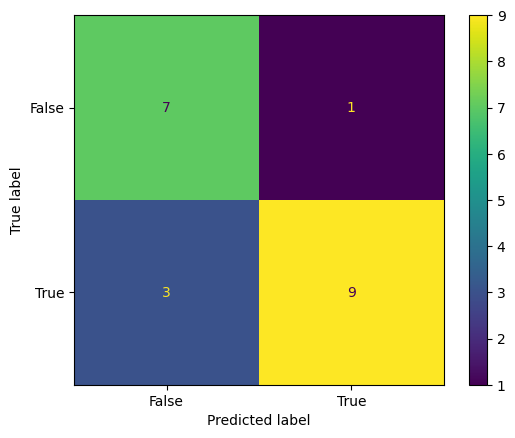

In [138]:
#Display the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(cm, display_labels=highQLabels)
disp.plot()
plt.show()

In [139]:
#Calculate the precision score: TP/(FP+TP) = 9/(1+9) = 0.9
from sklearn.metrics import precision_score
precision_score(y_true, y_pred)

0.9

In [140]:
#Calculate the recall score: TP/(FN+TP) = 9/(3+9) = 0.75
from sklearn.metrics import recall_score
recall_score(y_true, y_pred)

0.75

In [141]:
#Calculate the accuracy score: (TN+TP)/(TN+FP+TP+FN) = (7+9)/(7+1+9+3) = 0.8
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)

0.8

### Assignment 1: What does the performance measures mean?

Explain how the precission, recall and accuracy performance measures can make sense ?

What does that mean in our Portuguese wine case ?

Add text cells below for your answer.

Precision :

Betydning: Andelen af de instanser, som modellen har forudsagt som positive, der rent faktisk er korrekt klassificeret.

I vores vinkontekst: Dette fortæller os, hvor stor en procentdel af de vine, modellen har forudsagt som "høj kvalitet" (True), der i virkeligheden også er af høj kvalitet. Hvis modellen har en høj precision, kan vi stole på den, når den fortæller os, at en vin er god.

Recall :

Betydning: Andelen af alle de faktiske positive instanser, som modellen korrekt har klassificeret som positive.

I vores vinkontekst: Dette fortæller os, hvor stor en procentdel af alle de vine i datasættet, der faktisk er af "høj kvalitet", som modellen formåede at finde. En høj recall betyder, at modellen er god til ikke at overse de gode vine.

Accuracy :

Betydning: Andelen af alle instanser – både positive og negative – der er blevet klassificeret korrekt af modellen.

I vores vinkontekst: Dette er simpelthen den overordnede procentdel af samtlige vine, som modellen har gættet rigtigt på (både når den korrekt gætter, at en vin er af "høj kvalitet", og når den korrekt gætter, at den "ikke er af så høj kvalitet").

### Assignment 2: Importing data

Do the following:
1.   Please find the wines quality here:  
https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/WineQT.csv
2.   Run the next cell below to load the data in.


In [114]:
#Importing the dataset
datafile="https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/WineQT.csv"
dataset = pd.read_csv(datafile)
dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


###Assignment 3: Checking the dataset

Always do yourself a favour to check data:
1.   Extract information about the data structure with the `type` method in a cell code cell below.
2.   Check dataset with `info()` method provided by the `DataFrame` class in a cell code cell below.
3.   Is there any missing data in the dataset?
4.   State your observations on the dataset in a text cell below





In [115]:
display(dataset.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


State your observations on the dataset:
Dataset is of type DataFrame and there no missing values

3- Nej. Ud fra outputtet fra dataset.info() kan vi se, at alle kolonner har præcis 1143 "non-null" indgange, hvilket svarer til det totale antal rækker i datasættet. Der er derfor ingen manglende data.

4- Datasættet er indlæst som en Pandas DataFrame. Alt data i kolonnerne er numerisk (enten kommatal float64 eller heltal int64). Der er ingen tekststrenge, der skal konverteres. Ud over selve vinkvaliteten (quality) og identifikationsnummeret (Id) indeholder datasættet 11 forskellige kemiske egenskaber for vinene.

### Assignment 4: Selecting features and labels

Introduce code in the cells below that do the following:
1.   You may drop some features. E.g. with `dataset.drop(..., axis=1, inplace=True)`. Consider dropping some of the 'acidity' and 'sulfur' features, because the may depend on similar features.
2.   Extract the features with `X = dataset.iloc...`. Remember to leave out 'quality' and 'Id'
1.   Extract the quality class labels with `y = dataset["quality"].isin([6,7])` This will assign 'high quality' (`True` value) to wines having quality 6 or 7. The rest of the wines will then have their quality class labelled with `False`

Introduce one or more cells to carry what is mentioned above.

If time allows: you may also try experient with combining features






In [116]:
dataset.drop(['fixed acidity', 'total sulfur dioxide'], axis=1, inplace=True)

In [117]:
X = dataset.drop(['quality', 'Id'], axis=1)

In [118]:
y = dataset["quality"].isin([6, 7])

In [119]:
display(dataset.head())

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,0.70,0.00,1.9,0.076,11.0,0.9978,3.51,0.56,9.4,5,0
1,0.88,0.00,2.6,0.098,25.0,0.9968,3.20,0.68,9.8,5,1
2,0.76,0.04,2.3,0.092,15.0,0.9970,3.26,0.65,9.8,5,2
3,0.28,0.56,1.9,0.075,17.0,0.9980,3.16,0.58,9.8,6,3
4,0.70,0.00,1.9,0.076,11.0,0.9978,3.51,0.56,9.4,5,4


Introduce code in the cell below that stratifies the dataset:
1.   Import the `train_test_split` stratifier - that is: `from sklearn.model_selection import train_test_split`
2.   Split the dataset in training set and test set, where we stratify on the quality class labels - that is: `X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)`  

Check also the following references on `train_test_split`:
1.   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
2.   Chapter 2 and Python code base for chapter: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html




In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [120]:
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 857
Test set size: 286


### Assignment 5: Stratifying the dataset (continued)

Answer the following questions:
1.   What are the variables `X_train`, `X_test`, `y_train` and `y_test` going to be used for ?
2.   Explains the parameter `stratify=y` (Hint: Yes it has something to with stratifiction on quality class labels)

State your answers (e.g. in a cell below)


1- Stratificering er en metode til at inddele data, hvor man sikrer, at den oprindelige fordeling af en bestemt kategori (i dette tilfælde klassen/labelen) bevares, når man deler datasættet op i mindre dele (som et trænings- og testsæt).

2- Det er ekstremt vigtigt at stratificere på vores kvalitets-labels for at sikre, at både vores træningssæt og testsæt indeholder den nøjagtig samme procentdel af vine af "høj kvalitet" som det samlede, oprindelige datasæt. Hvis vi bare delte dataene helt tilfældigt, kunne vi risikere, at testsættet næsten ingen vine af "høj kvalitet" fik, og så ville vi ikke kunne vurdere præcist, hvor god modellen er til at genkende dem.

### Assignment 6: Establish the MLP Classifier and pipeline

Do the following in the cell below to establish a Multi Layer Perceptron:
1.   Import the classifier - that is: `from sklearn.neural_network import MLPClassifier`
2.   Import the standard scaler - that is: `from sklearn.preprocessing import StandardScaler`
1.   Import pipelining - that is: `from sklearn.pipeline import make_pipeline`
2.   Establish the MLP Classifier - that is something like this `MLPClassifier(hidden_layer_sizes=[5], activation="relu" , max_iter=10_000, random_state=42)`
1.   Establish a pipeline containing `MLPClassifier` and `StandardScaler`- that is something like this:  `make_pipeline(StandardScaler(), ...)`



Also check the following references:
1.   MLP Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html and Chapter 10 including code reference for this chapter: https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb
2.   Standard scaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html and chapter 2
1.   Pipelining: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html and  chapter 2






In [123]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42))
])

### Assignment 7: Establish the MLP Classifier and pipeline (continued)

Answer the following questions (e.g. in a cell below):
1.   Why is it important to apply the `StandardScaler` ?
2.   What is the point on establishing a pipeline ?
1.   Explain the `hidden_layer_sizes` parameter.
2.   Explain the `activation` paramater.
1.   Explain the `max_iter` parameter.       
2.   Explain the `random_state` parameter.
1.   Can you find out how many layers perceptron has (hint: look after an attribute) ?










1-
Det er vigtigt, fordi neurale netværk (som MLPClassifier) er meget følsomme over for skalaen af inputdataene. Hvis forskellige features (f.eks. alkoholprocent vs. mængden af svovldioxid) har meget forskellige numeriske skalaer, vil netværkets matematiske optimering (gradient descent) have svært ved at finde vej, og det vil tage længere tid at lære. StandardScaler sørger for, at alle features får samme skala (typisk med en gennemsnitsværdi på 0 og en standardafvigelse på 1), så de bidrager ligeligt.

2-
En pipeline samler flere trin (f.eks. dataskalering og selve maskinlæringsmodellen) til ét enkelt objekt. Det gør koden meget mere overskuelig. Men vigtigst af alt sikrer det, at vi undgår "data leakage" (datalækage). Pipelinen sørger automatisk for, at skaleringen kun beregnes ud fra træningsdataene og derefter genbruges på testdataene, så modellen ikke ved et uheld får "smugkigget" på testdataene under træningen.

3 -
Dette parameter bestemmer arkitekturen for netværkets skjulte lag ("hidden layers"). Den tager en liste/tuple af tal, hvor hvert tal repræsenterer antallet af neuroner (noder) i et specifikt lag. F.eks. betyder (50,) at der er præcis ét skjult lag med 50 neuroner i alt. Havde det været (50, 20), ville der være to skjulte lag med hhv. 50 og 20 neuroner.

4 -
Aktiveringsfunktionen er det, der bestemmer, om (og hvor kraftigt) signalet fra en neuron sendes videre til næste lag i netværket. Almindelige funktioner er 'relu', 'tanh', eller 'logistic'. Det vigtigste ved aktiveringsfunktionen er, at den introducerer "ikke-linearitet" i systemet. Uden den ville netværket kun kunne lære simple, lige linjer – men med den kan netværket lære at genkende utroligt komplekse og kurvede mønstre i dataene.

5 -
Dette er det maksimale antal gange (ofte kaldet "epochs"), som modellen må løbe igennem hele træningsdatasættet for at lære og justere sine vægte. Hvis netværket stadig prøver at forbedre sig, men rammer max_iter, så tvinges det til at stoppe.

6 -
Dette parameter bruges til at kontrollere den tilfældighed, der sker i opstarten af modellen (f.eks. når startvægtene i neuronerne tildeles tilfældige værdier). Ved at sætte et fast tal (som 42) "låser" vi tilfældigheden fast, så vi er garanteret at få præcis samme resultat hver eneste gang, vi kører koden. Det sikrer, at vores forsøg er reproducerbare.

In [129]:
mlp_model = mlp_pipeline.named_steps['mlp']
print(f"Antal lag i netværket: {mlp_model.n_layers_}")

Antal lag i netværket: 3




---



### Assignment 8: Fitting the model

Fit the model by calling the `fit` method on the pipeline in the cell below


In [125]:
mlp_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=500,
                               random_state=42))])

### Assignment 9: Fitting the model (continued)

Answer the following question(s) (e.g. in a cell below):
1.   What does it actually mean to fit a model ?
1.   What does specifically mean in our wine case model ?







1-
At "fitte" (eller træne) en model betyder, at man lader maskinlæringsalgoritmen analysere træningsdataene for at lære de underliggende mønstre og sammenhænge mellem inputs (features) og outputs (labels). For vores neurale netværk (MLP) betyder det helt specifikt, at modellen matematiske justerer sine interne "vægte" (weights) og "bias" igennem flere forsøg (iterationer/epochs), så dens fejl (forskellen på modellens gæt og de rigtige svar) bliver så lille som muligt.

2-
I vores specifikke case med Vino Verde-vin betyder fit, at vi beder modellen om at kigge på de kemiske egenskaber for hver vin i vores træningssæt (X_train – f.eks. alkoholprocent, pH-værdi, restsukker osv.) og finde ud af, hvordan disse egenskaber hænger sammen med vinens kvalitetsmærkat (y_train – om vinen er af "høj kvalitet" (kvalitet 6 eller 7) eller ej). Modellen lærer kort sagt "opskriften" på, hvilken kemisk sammensætning der typisk resulterer i en god vin, så den senere kan bruge denne viden til at bedømme nye, ukendte vine.

### Assignment 10: Observing the models score

Do the following in the cells below to calculate the models accuracy score:
1.   Calculate the accuracy score on the training set - that is: `pipeline.score(X_train, y_train)` in its own cell
2.   Calculate the accuracy score on the test set - that is: `pipeline.score(X_test, y_test)` in its own cell

Also Check the following references on pipelining:
1.   Score method: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.score


In [126]:
# Beregn og udskriv accuracy på træningssættet
train_score = mlp_pipeline.score(X_train, y_train)
print(f"Accuracy på træningssættet: {train_score:.4f}")

Accuracy på træningssættet: 0.8086


In [127]:
# Beregn og udskriv accuracy på testsættet
test_score = mlp_pipeline.score(X_test, y_test)
print(f"Accuracy på testsættet: {test_score:.4f}")

Accuracy på testsættet: 0.7413


### Assignment 11: Observing the models score (continued)





Observe among other things on the underfit and overfit conditions:
1.   Try different settings of `hidden_layer_sizes` and  `activation` parameters
2.   Try dropping out and/or combine features
1.   What do you observe?

State your answers and observations (e.g. in a cell below)





In [128]:

X_train_dropped = X_train.drop(['alcohol', 'volatile acidity', 'pH'], axis=1)
X_test_dropped = X_test.drop(['alcohol', 'volatile acidity', 'pH'], axis=1)

dropped_pipeline = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
)

dropped_pipeline.fit(X_train_dropped, y_train)

print("--- MODEL MED FÆRRE FEATURES (Dropping) ---")
print(f"Trænings-score: {dropped_pipeline.score(X_train_dropped, y_train):.4f}")
print(f"Test-score:     {dropped_pipeline.score(X_test_dropped, y_test):.4f}")

--- MODEL MED FÆRRE FEATURES (Dropping) ---
Trænings-score: 0.7433
Test-score:     0.6958


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


1-

Underfitting (For simpel model): Hvis jeg sætter hidden_layer_sizes til noget meget lavt (f.eks. (2,) eller (5,)) og bruger en svagere aktiveringsfunktion som logistic, observerer jeg underfitting. Modellen har simpelthen ikke nok "hjernekapacitet" (neuroner) til at fange de komplekse, ikke-lineære sammenhænge i vinenes kemi. Både min accuracy på træningssættet og testsættet vil være lav.

Overfitting (For kompleks model): Hvis jeg derimod bygger et gigantisk netværk med mange lag og neuroner (f.eks. hidden_layer_sizes=(500, 500)) kombineret med relu, begynder modellen at overfitte. Jeg vil observere, at scoren på træningssættet bliver ekstremt høj (næsten 1.0 ) min var (0.9965), fordi modellen "memorerer" træningsdataene. Til gengæld vil scoren på testsættet ikke følge med op, men måske endda falde, fordi modellen fanger støj og ikke kan generalisere til nye vine.

2- Fjernelse af vigtige features: Hvis jeg fjerner afgørende funktioner (som f.eks. alcohol eller volatile acidity), mangler modellen vigtig information for at kunne kende forskel på god og dårlig vin. Dette fører til underfitting og dårligere scores over hele linjen.

Fjernelse af overlappende/støjende features: Som vi gjorde tidligere ved at droppe features, der mindede om hinanden (f.eks. redundant syre eller svovl), reducerer vi kompleksiteten af vores input. Dette modvirker overfitting, da modellen får mindre "støj" at forholde sig til, hvilket ofte bringer trænings-scoren og test-scoren tættere på hinanden og forbedrer modellens evne til at generalisere.

### Assignment 12: Confusion Matrix and performance measures (revisited)



Repeat assignment 1 with MLP Classifiers' score fitted with the Vino Verde wines dataset

--- PERFORMANCE MEASURES ---
Accuracy:  0.7413
Precision: 0.7484
Recall:    0.7682



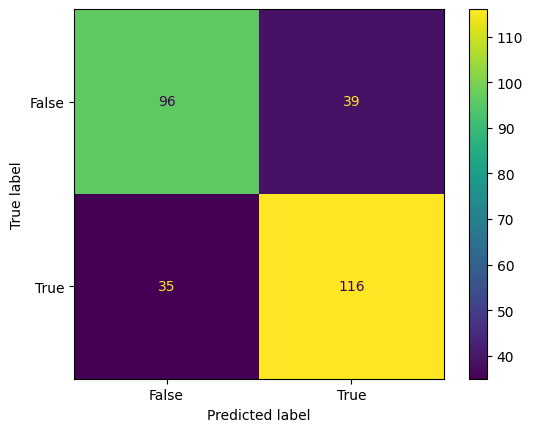

In [146]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt

y_pred = mlp_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("--- PERFORMANCE MEASURES ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=highQLabels)
disp.plot()
plt.show()

### Assignment 13:Try with other classifiers - Extra

For the fast ones

Try to get a better a performance by applying another classifier algorithm